In [14]:
# Run this once to install everything needed
!pip install requests feedparser newspaper3k textblob scikit-learn pandas matplotlib wordcloud newsapi-python
!python -m textblob.download_corpora


[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Finished.


[nltk_data] Downloading package brown to
[nltk_data]     C:\Users\leona\AppData\Roaming\nltk_data...
[nltk_data]   Package brown is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\leona\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\leona\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     C:\Users\leona\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package conll2000 to
[nltk_data]     C:\Users\leona\AppData\Roaming\nltk_data...
[nltk_data]   Package conll2000 is already up-to-date!
[nltk_data] Downloading package movie_reviews to
[nltk_data]     C:\Users\leona\AppData\Roaming\nltk_data...
[nltk_data]   Package movie_reviews is alr

In [15]:
import feedparser
import pandas as pd

# News RSS feeds (free, no key needed)
rss_feeds = {
    "BBC": "http://feeds.bbci.co.uk/news/rss.xml",
    "Reuters": "https://feeds.reuters.com/reuters/topNews",
    "AP News": "https://feeds.apnews.com/rss/apf-topnews",
    "Google News": "https://news.google.com/rss"
}

articles = []

for source, url in rss_feeds.items():
    feed = feedparser.parse(url)
    for entry in feed.entries[:10]:  # Get top 10 from each source
        articles.append({
            "source": source,
            "title": entry.get("title", ""),
            "summary": entry.get("summary", ""),
            "link": entry.get("link", "")
        })
    print(f"✅ {source}: {len(feed.entries)} articles fetched")

# Store in a table
df = pd.DataFrame(articles)
print(f"\n📰 Total articles fetched: {len(df)}")
df.head()

✅ BBC: 38 articles fetched
✅ Reuters: 0 articles fetched
✅ AP News: 0 articles fetched
✅ Google News: 37 articles fetched

📰 Total articles fetched: 20


,source,title,summary,link
0,BBC,Checkpoints everywhere and queues for bread: F...,"Iranians are coping with daily strikes, intern...",https://www.bbc.com/news/articles/cj4zze5lzjpo...
1,BBC,Defence minister in Cyprus after criticism of ...,The Cypriot government has criticised how the ...,https://www.bbc.com/news/articles/c0e55y0pzgwo...
2,BBC,How depleted weapons stockpiles could affect t...,Weapons stocks will not alone decide the outco...,https://www.bbc.com/news/articles/cdxzzqe82d2o...
3,BBC,US Senate vote fails to rein in Trump war powe...,"The measure, passed largely along party lines,...",https://www.bbc.com/news/articles/c5yjj28jjd0o...
4,BBC,"US sub sinks Iranian warship in Indian Ocean, ...",Sri Lanka's navy says around 140 people are fe...,https://www.bbc.com/news/articles/c0e55g03v2zo...


In [16]:
from textblob import TextBlob

def get_sentiment(text):
    analysis = TextBlob(str(text))
    polarity = analysis.sentiment.polarity
    if polarity > 0.1:
        return "Positive 😊"
    elif polarity < -0.1:
        return "Negative 😟"
    else:
        return "Neutral 😐"

# Apply sentiment to every headline
df["sentiment"] = df["title"].apply(get_sentiment)

# Count results
sentiment_counts = df["sentiment"].value_counts()
print("📊 Sentiment Breakdown:")
print(sentiment_counts)
print()

# Show sample
df[["source", "title", "sentiment"]].head(10)

📊 Sentiment Breakdown:
sentiment
Neutral 😐     16
Negative 😟     2
Positive 😊     2
Name: count, dtype: int64



,source,title,sentiment
0,BBC,Checkpoints everywhere and queues for bread: F...,Neutral 😐
1,BBC,Defence minister in Cyprus after criticism of ...,Neutral 😐
2,BBC,How depleted weapons stockpiles could affect t...,Neutral 😐
3,BBC,US Senate vote fails to rein in Trump war powe...,Negative 😟
4,BBC,"US sub sinks Iranian warship in Indian Ocean, ...",Neutral 😐
5,BBC,South East Water faces £22m fine for supply fa...,Positive 😊
6,BBC,Asylum seekers who break law to have support r...,Neutral 😐
7,BBC,Dentists who failed to see enough NHS patients...,Negative 😟
8,BBC,Allergy training to be compulsory in schools i...,Neutral 😐
9,BBC,My natural way of playing has been coached out...,Neutral 😐


In [17]:
def categorize_topic(text):
    text = text.lower()
    
    if any(word in text for word in ["war", "attack", "military", "missile", "strike", "army", "weapon"]):
        return "⚔️ War & Conflict"
    elif any(word in text for word in ["election", "president", "government", "minister", "senate", "congress", "vote"]):
        return "🏛️ Politics"
    elif any(word in text for word in ["stock", "economy", "market", "inflation", "bank", "trade", "dollar"]):
        return "💰 Economy"
    elif any(word in text for word in ["climate", "weather", "earthquake", "flood", "storm", "fire"]):
        return "🌍 Environment"
    elif any(word in text for word in ["ai", "tech", "apple", "google", "microsoft", "robot", "cyber"]):
        return "💻 Technology"
    elif any(word in text for word in ["health", "virus", "cancer", "hospital", "drug", "vaccine", "disease"]):
        return "🏥 Health"
    elif any(word in text for word in ["sport", "football", "basketball", "olympic", "tennis", "soccer"]):
        return "⚽ Sports"
    else:
        return "📌 General"

# Apply to all headlines
df["topic"] = df["title"].apply(categorize_topic)

# Count topics
topic_counts = df["topic"].value_counts()
print("🗂️ Topic Breakdown:")
print(topic_counts)
print()

df[["source", "title", "topic"]].head(10)

🗂️ Topic Breakdown:
topic
💻 Technology         10
⚔️ War & Conflict     5
📌 General             3
🏛️ Politics           1
💰 Economy             1
Name: count, dtype: int64



,source,title,topic
0,BBC,Checkpoints everywhere and queues for bread: F...,⚔️ War & Conflict
1,BBC,Defence minister in Cyprus after criticism of ...,⚔️ War & Conflict
2,BBC,How depleted weapons stockpiles could affect t...,⚔️ War & Conflict
3,BBC,US Senate vote fails to rein in Trump war powe...,⚔️ War & Conflict
4,BBC,"US sub sinks Iranian warship in Indian Ocean, ...",⚔️ War & Conflict
5,BBC,South East Water faces £22m fine for supply fa...,💻 Technology
6,BBC,Asylum seekers who break law to have support r...,📌 General
7,BBC,Dentists who failed to see enough NHS patients...,🏛️ Politics
8,BBC,Allergy training to be compulsory in schools i...,💻 Technology
9,BBC,My natural way of playing has been coached out...,📌 General


C:\Users\leona\AppData\Local\Temp\ipykernel_12396\2052071031.py:34: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\leona\AppData\Local\Temp\ipykernel_12396\2052071031.py:34: UserWarning: Glyph 128187 (\N{PERSONAL COMPUTER}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\leona\AppData\Local\Temp\ipykernel_12396\2052071031.py:34: UserWarning: Glyph 128204 (\N{PUSHPIN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\leona\AppData\Local\Temp\ipykernel_12396\2052071031.py:34: UserWarning: Glyph 127963 (\N{CLASSICAL BUILDING}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\leona\AppData\Local\Temp\ipykernel_12396\2052071031.py:34: UserWarning: Glyph 128176 (\N{MONEY BAG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\leona\AppData\Local\Temp\ipykernel_12396\2052071031.py:34: UserWarning: Glyph 128450 (\N{CARD INDEX DIVIDERS}) missing from font(s) DejaVu Sans.
  plt.

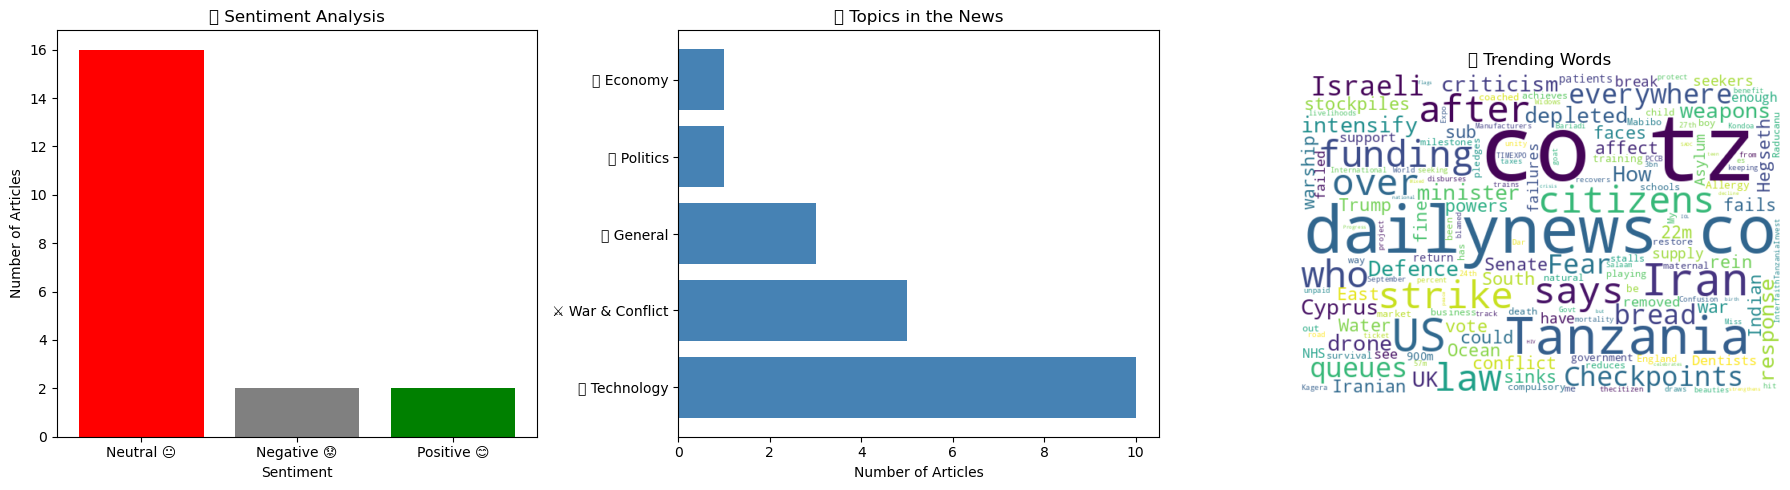


🔥 Top Trending Topics Today:
  Tanzania: mentioned 4 times
  Iran: mentioned 3 times
  Checkpoints: mentioned 1 times
  Fear: mentioned 1 times
  Israeli: mentioned 1 times
  Defence: mentioned 1 times
  Cyprus: mentioned 1 times
  How: mentioned 1 times
  Senate: mentioned 1 times
  Trump: mentioned 1 times


In [18]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from collections import Counter
import re

# --- Chart 1: Sentiment Bar Chart ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sentiment_counts = df["sentiment"].value_counts()
axes[0].bar(sentiment_counts.index, sentiment_counts.values, 
            color=["red", "gray", "green"])
axes[0].set_title("📊 Sentiment Analysis")
axes[0].set_xlabel("Sentiment")
axes[0].set_ylabel("Number of Articles")

# --- Chart 2: Topic Bar Chart ---
topic_counts = df["topic"].value_counts()
axes[1].barh(topic_counts.index, topic_counts.values, color="steelblue")
axes[1].set_title("🗂️ Topics in the News")
axes[1].set_xlabel("Number of Articles")

# --- Chart 3: Word Cloud of Headlines ---
all_titles = " ".join(df["title"].tolist())
# Remove common words
stopwords = {"the", "a", "an", "in", "on", "at", "to", "of", "and", "or", 
             "is", "are", "was", "were", "for", "with", "as", "by", "it"}
wordcloud = WordCloud(width=600, height=400, 
                      stopwords=stopwords,
                      background_color="white").generate(all_titles)
axes[2].imshow(wordcloud, interpolation="bilinear")
axes[2].axis("off")
axes[2].set_title("🔥 Trending Words")

plt.tight_layout()
plt.show()

# --- Top Trending Topics (word frequency) ---
words = re.findall(r'\b[A-Z][a-z]+\b', " ".join(df["title"].tolist()))
top_words = Counter(words).most_common(10)
print("\n🔥 Top Trending Topics Today:")
for word, count in top_words:
    print(f"  {word}: mentioned {count} times")

In [19]:
# Final combined view of all analysis
print("=" * 70)
print("📰 TODAY'S NEWS ANALYSIS DASHBOARD")
print("=" * 70)

print(f"\n✅ Total Articles Analysed: {len(df)}")
print(f"📡 Sources: {', '.join(df['source'].unique())}")

print("\n" + "=" * 70)
print("📊 SENTIMENT SUMMARY")
print("=" * 70)
for sentiment, count in df["sentiment"].value_counts().items():
    pct = round(count / len(df) * 100)
    print(f"  {sentiment}: {count} articles ({pct}%)")

print("\n" + "=" * 70)
print("🗂️ TOPIC SUMMARY")
print("=" * 70)
for topic, count in df["topic"].value_counts().items():
    pct = round(count / len(df) * 100)
    print(f"  {topic}: {count} articles ({pct}%)")

print("\n" + "=" * 70)
print("📰 ALL HEADLINES WITH ANALYSIS")
print("=" * 70)

for i, row in df.iterrows():
    print(f"\n[{row['source']}] {row['topic']} | {row['sentiment']}")
    print(f"  📌 {row['title']}")

print("\n" + "=" * 70)
print("✅ Analysis Complete!")
print("=" * 70)

📰 TODAY'S NEWS ANALYSIS DASHBOARD

✅ Total Articles Analysed: 20
📡 Sources: BBC, Google News

📊 SENTIMENT SUMMARY
  Neutral 😐: 16 articles (80%)
  Negative 😟: 2 articles (10%)
  Positive 😊: 2 articles (10%)

🗂️ TOPIC SUMMARY
  💻 Technology: 10 articles (50%)
  ⚔️ War & Conflict: 5 articles (25%)
  📌 General: 3 articles (15%)
  🏛️ Politics: 1 articles (5%)
  💰 Economy: 1 articles (5%)

📰 ALL HEADLINES WITH ANALYSIS

[BBC] ⚔️ War & Conflict | Neutral 😐
  📌 Checkpoints everywhere and queues for bread: Fear in Iran as US-Israeli strikes intensify

[BBC] ⚔️ War & Conflict | Neutral 😐
  📌 Defence minister in Cyprus after criticism of UK's drone strike response

[BBC] ⚔️ War & Conflict | Neutral 😐
  📌 How depleted weapons stockpiles could affect the Iran conflict

[BBC] ⚔️ War & Conflict | Negative 😟
  📌 US Senate vote fails to rein in Trump war powers on Iran

[BBC] ⚔️ War & Conflict | Neutral 😐
  📌 US sub sinks Iranian warship in Indian Ocean, Hegseth says

[BBC] 💻 Technology | Positive 😊
 

In [21]:
import smtplib
from email.mime.multipart import MIMEMultipart
from email.mime.text import MIMEText

# 🔧 FILL IN YOUR DETAILS HERE
SENDER_EMAIL = "leonarddickson268@gmail.com"
RECEIVER_EMAIL = "beulahdickson6@gmail.com"
APP_PASSWORD = "ndea wsam alhi mazf"

def send_news_report(df):
    # Build email content
    msg = MIMEMultipart("alternative")
    msg["Subject"] = f"📰 Your Daily News Report — {pd.Timestamp.now().strftime('%B %d, %Y')}"
    msg["From"] = SENDER_EMAIL
    msg["To"] = RECEIVER_EMAIL

    # Build HTML email body
    html = f"""
    <h2>📰 Today's News Analysis</h2>
    <p>✅ <b>{len(df)} articles</b> analysed from {', '.join(df['source'].unique())}</p>

    <h3>📊 Sentiment Summary</h3>
    <ul>
    {"".join(f"<li>{s}: {c} articles</li>" for s, c in df['sentiment'].value_counts().items())}
    </ul>

    <h3>🗂️ Topic Summary</h3>
    <ul>
    {"".join(f"<li>{t}: {c} articles</li>" for t, c in df['topic'].value_counts().items())}
    </ul>

    <h3>📰 Top Headlines</h3>
    <table border="1" cellpadding="8" cellspacing="0" style="border-collapse:collapse; width:100%;">
        <tr style="background-color:#f2f2f2;">
            <th>Source</th>
            <th>Headline</th>
            <th>Topic</th>
            <th>Sentiment</th>
            <th>Link</th>
        </tr>
        {"".join(f'''
        <tr>
            <td><b>{row['source']}</b></td>
            <td>{row['title']}</td>
            <td>{row['topic']}</td>
            <td>{row['sentiment']}</td>
            <td><a href="{row['link']}" target="_blank">Read More 🔗</a></td>
        </tr>''' for _, row in df.iterrows())}
    </table>

    <br>
    <p><i>Generated automatically by your Jupyter News Analyser 🤖</i></p>
    """

    msg.attach(MIMEText(html, "html"))

    # Send email
    with smtplib.SMTP_SSL("smtp.gmail.com", 465) as server:
        server.login(SENDER_EMAIL, APP_PASSWORD)
        server.sendmail(SENDER_EMAIL, RECEIVER_EMAIL, msg.as_string())
    
    print("✅ Email sent successfully!")

# Send it!
send_news_report(df)

✅ Email sent successfully!
